# Poisson Sport Model

In [1]:
using Pkg

Pkg.activate(pwd())
Pkg.instantiate()
Pkg.status()

  Activating project at `~/codes/Julia/MyPack/CornucopiaMLE`


Project CornucopiaMLE v0.1.0
Status `~/codes/Julia/MyPack/CornucopiaMLE/Project.toml`
  [6e4b80f9] BenchmarkTools v1.6.0
  [0e736298] Bessels v0.2.8
  [336ed68f] CSV v0.10.15
  [88a5189c] DataAugmentation v0.3.2
  [a93c6f00] DataFrames v1.7.0
  [8bb1440f] DelimitedFiles v1.9.1
  [b4f34e82] Distances v0.10.12
⌃ [31c24e10] Distributions v0.25.117
⌃ [5789e2e9] FileIO v1.16.6
  [587475ba] Flux v0.16.3
  [38e38edf] GLM v1.9.0
⌃ [87dc4568] HiGHS v1.13.0
  [02fcd773] ImageTransformations v0.10.1
⌃ [916415d5] Images v0.26.1
⌃ [4076af6c] JuMP v1.24.0
  [b964fa9f] LaTeXStrings v1.4.0
⌃ [bdcacae8] LoopVectorization v0.12.171
  [eb30cadb] MLDatasets v0.7.18
  [b51810bb] MatrixDepot v1.0.13
  [dbeba491] Metalhead v0.9.5
  [86f7a689] NamedArrays v0.10.3
⌅ [7e02d93a] OptimalTransport v0.1.9
⌃ [91a5bcdd] Plots v1.40.9
  [08abe8d2] PrettyTables v2.4.0
⌃ [6f49c342] RCall v0.14.6
⌃ [276daf66] SpecialFunctions v2.5.0
  [10745b16] Statistics v1.11.1
⌃ [2913bbd2] StatsBase v0.34.4
  [ac1d9e8a] ThreadsX v0.1

In [2]:
using CSV, DataFrames, Pkg, SpecialFunctions, Statistics, CornucopiaMLE, RCall, DataFrames, Random, StatsBase
using BenchmarkTools, NamedArrays, Pkg, Distributions, PrettyTables, LinearAlgebra, MatrixDepot
using Plots, LaTeXStrings, Bessels, Printf


[ Info: verify download of index files...
[ Info: reading database


EOFError()


┌ Warning: recreating database file
└ @ MatrixDepot ~/.julia/packages/MatrixDepot/4S7Oa/src/download.jl:59
[ Info: reading index files
[ Info: adding metadata...
[ Info: adding svd data...
[ Info: writing database
┌ Warning: exception during initialization: 'KeyError(MatrixDepot)'
└ @ MatrixDepot ~/.julia/packages/MatrixDepot/4S7Oa/src/MatrixDepot.jl:125


## Clean data: 2002-2003 season NBA games

In [3]:
rawdata = CSV.read("src/datasets/nba_cleaned.txt", DataFrame; header=true)
team_names = (rawdata[!, 1] ∪ rawdata[!, 3]) |> sort |> unique
n = length(team_names)
# p_ij is the points team i scores against j
P = NamedArray(zeros(n, n), (team_names, team_names))
# t_ij is the game length team i plays against j
T = NamedArray(zeros(n, n), (team_names, team_names))
# accumulate summary statistics
for row in eachrow(rawdata)
    t1 = row[:team1_name]
    t2 = row[:team2_name]
    s1 = row[:team1_score]
    s2 = row[:team2_score]
    l  = row[:game_length]
    P[t1, t2] += s1
    P[t2, t1] += s2
    T[t1, t2] += l
    T[t2, t1] += l
end

In [4]:
P

29×29 Named Matrix{Float64}
                 A ╲ B │          Atlanta Hawks  …      Washington Wizards
───────────────────────┼──────────────────────────────────────────────────
Atlanta Hawks          │                    0.0  …                   367.0
Boston Celtics         │                  300.0                      349.0
Chicago Bulls          │                  398.0                      377.0
Cleveland Cavaliers    │                  386.0                      354.0
Dallas Mavericks       │                  222.0                      198.0
Denver Nuggets         │                  173.0                      162.0
Detroit Pistons        │                  375.0                      354.0
Golden State Warriors  │                  231.0                      217.0
Houston Rockets        │                  176.0                      191.0
Indiana Pacers         │                  385.0                      370.0
Los Angeles Clippers   │                  173.0                      184

In [5]:
T

29×29 Named Matrix{Float64}
                 A ╲ B │          Atlanta Hawks  …      Washington Wizards
───────────────────────┼──────────────────────────────────────────────────
Atlanta Hawks          │                    0.0  …                   192.0
Boston Celtics         │                  154.0                      197.0
Chicago Bulls          │                  192.0                      192.0
Cleveland Cavaliers    │                  197.0                      192.0
Dallas Mavericks       │                   96.0                      101.0
Denver Nuggets         │                   96.0                       96.0
Detroit Pistons        │                  197.0                      197.0
Golden State Warriors  │                   96.0                       96.0
Houston Rockets        │                   96.0                      101.0
Indiana Pacers         │                  197.0                      202.0
Los Angeles Clippers   │                   96.0                       96

In [6]:
@benchmark PoiSpoModel(P, T)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  29.208 μs … 70.292 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     33.125 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   32.676 μs ±  2.344 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

                     ▅█▆                                       
  ▁▄█▇▇▅▃▂▃▃▂▂▂▂▂▂▂▂▅███▇▅▃▃▄▂▂▁▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▂
  29.2 μs         Histogram: frequency by time        40.8 μs <

 Memory estimate: 15.41 KiB, allocs estimate: 239.

In [7]:
@benchmark PoiSpoModelNR(P, T)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  152.333 μs …   6.063 ms  ┊ GC (min … max): 0.00% … 96.95%
 Time  (median):     184.292 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   194.319 μs ± 118.784 μs  ┊ GC (mean ± σ):  5.61% ±  9.87%

    ▁▅█                                                          
  ▃▅███▇▃▂▂▂▂▂▂▂▁▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▁▂▂▂▁▂▂▂▂▂▂▂▂▂ ▂
  152 μs           Histogram: frequency by time          639 μs <

 Memory estimate: 450.16 KiB, allocs estimate: 186.

# MLEs of Parameters for Univariate Distributions with VGAM Package

In [8]:
distributions = ["yule", "cauchy", "weibull", "gamma", "logarithmic", "gumbel"]
mle_functions = [mle_yule_simon, mle_Cauchy, mle_weibull, mle_gamma, mle_logarithmic, mle_gumbel]

MLE_Parameter1 = []
MLE_Parameter2 = []
Convergence = []
MLE_MM_Parameter1 = []
MLE_MM_Parameter2 = []
LogLikR = []
LogLikMM = []
TimeR = []
TimeMM = []
Iter_MM = []
Iter_R = []


## Parameter settings
R"""
library(VGAM)
library(bench)
set.seed(123)
shape = 3
scale = 1
# shape = 0.1
# scale = 10
n = 100
m = 10

data_yule <- as.numeric(ryules(n*m, shape))  
data_cauchy <- as.numeric(rcauchy(n*m, shape, scale))  
data_weibull <- as.numeric(rweibull(n*m, shape, scale))  
data_gamma <- as.numeric(rgamma(n*m, shape, scale))  
data_logarithmic <- as.numeric(rlog(n*m, shape/(1+shape)))  
data_gumbel <- as.numeric(rgumbel(n*m, shape, scale))  

fit_model <- function(data, dist, warn_name) {
  warn_msgs <<- get("warn_msgs", envir = .GlobalEnv)
  result <- tryCatch(
    {
      bm <- bench::mark( res <- vglm(data ~ 1, dist, trace = FALSE))
      iterations <- slot(res, "iter")
      list(result = res, time = bm$median, iterations = iterations)
    },
    warning = function(w) {
      warn_msgs[[warn_name]] <<- NaN
      bm <- bench::mark( res <- vglm(data ~ 1, dist, trace = FALSE))
      iterations <- slot(res, "iter")
      list(result = res, time = bm$median, iterations = iterations)
    },
    error = function(e) {
      warn_msgs[[warn_name]] <<- "Error"
      list(result = NaN, time = NaN, iterations = NaN)
    }
  )
  return(result)
}

warn_msgs <- list(
  yule = 1,
  cauchy = 1,
  weibull = 1,
  gamma = 1,
  logarithmic = 1,
  gumbel = 1
)

result_all = matrix(0,6*m,5)
for(k in c(1:m)){

  index1 = c(1:n) + (k-1)*n
  index2 = c(1:6) + (k-1)*6
  fit_yule <- fit_model(data_yule[index1], yulesimon, "yule")
  fit_cauchy <- fit_model(data_cauchy[index1], cauchy, "cauchy")
  fit_weibull <- fit_model(data_weibull[index1], weibullR, "weibull")
  fit_gamma <- fit_model(data_gamma[index1], gamma2, "gamma")
  fit_logarithmic <- fit_model(data_logarithmic[index1], logff, "logarithmic")
  fit_gumbel <- fit_model(data_gumbel[index1], gumbel, "gumbel")
  
  result <- list(
    yule = if (!is.nan(warn_msgs$yule) && warn_msgs$yule != "Error") c(exp(coef(fit_yule$result)), NA, fit_yule$iterations, fit_yule$time, 1) else c(NA, NA, 0, NA, 0),
    cauchy = if (!is.nan(warn_msgs$cauchy) && warn_msgs$cauchy != "Error") c(coef(fit_cauchy$result)[1], exp(coef(fit_cauchy$result))[2], fit_cauchy$iterations,  fit_cauchy$time, 1) else c(NA, NA, 0, NA, 0),
    weibull = if (!is.nan(warn_msgs$weibull) && warn_msgs$weibull != "Error") c(exp(coef(fit_weibull$result))[2], exp(coef(fit_weibull$result))[1], fit_weibull$iterations,  fit_weibull$time, 1) else c(NA, NA, 0, NA, 0),
    gamma = if (!is.nan(warn_msgs$gamma) && warn_msgs$gamma != "Error") c(exp(coef(fit_gamma$result))[2], exp(coef(fit_gamma$result))[2] / exp(coef(fit_gamma$result))[1], fit_gamma$iterations,  fit_gamma$time, 1) else c(NA, NA, 0, NA, 0),
    logarithmic = if (!is.nan(warn_msgs$logarithmic) && warn_msgs$logarithmic != "Error") c(logitlink(coef(fit_logarithmic$result), inverse = TRUE), NA, fit_logarithmic$iterations,  fit_logarithmic$time, 1) else c(NA, NA, 0, NA, 0),
    gumbel = if (!is.nan(warn_msgs$gumbel) && warn_msgs$gumbel != "Error") c(coef(fit_gumbel$result)[1], exp(coef(fit_gumbel$result))[2], fit_gumbel$iterations,  fit_gumbel$time, 1) else c(NA, NA, 0, NA, 0)
  )
  
  result_all[index2,] =  do.call(rbind, result)
}


result_warnings <- warn_msgs
list(result_all, result_warnings)
""" |> rcopy

# subtract results from R
mle_values = R"result_all"
mle_values = convert(Array, mle_values)

# loglikelihood
function calculate_loglikelihood(distribution, params, data)
    try
        if distribution == "yule"
            function loglik_yule(ρ, x)
                sum(length(x) * log(ρ) .+ loggamma.(x .+ ρ) .- loggamma.(ρ))
            end
            return loglik_yule(params[1], data)
        elseif distribution == "logarithmic"
            function loglik_logarithmic(p, x)
                sum(-log(-log(1 - p)) .+ log.(x) .* log(p) .- log.(x))
            end
            return loglik_logarithmic(params[1], data)
        elseif distribution == "cauchy"
            return loglikelihood(Cauchy(params[1], params[2]), data)
        elseif distribution == "weibull"
            return loglikelihood(Weibull(params[1], params[2]), data)
        elseif distribution == "gamma"
            return loglikelihood(Gamma(params[1], params[2]), data)
        elseif distribution == "gumbel"
            return loglikelihood(Gumbel(params[1], params[2]), data)
        end
    catch e
        if e isa DomainError
            println("DomainError encountered during log-likelihood computation for $distribution. Returning NaN.")
            return NaN
        else
            rethrow(e)
        end
    end
end



┌ Warning: RCall.jl: Loading required package: stats4
│ Loading required package: splines
└ @ RCall ~/.julia/packages/RCall/0ggIQ/src/io.jl:172


calculate_loglikelihood (generic function with 1 method)

In [9]:
MLE_Parameter1 = []
MLE_Parameter2 = []
Convergence = []
MLE_MM_Parameter1 = []
MLE_MM_Parameter2 = []
LogLikR = []
LogLikMM = []
TimeR = []
TimeMM = []
Iter_MM = []
Iter_R = []

n = 100
m = 6
for k in 1:10
    diss1 = 0
    for (dist, mle_func) in zip(distributions, mle_functions)
        diss1 += 1
        data_name = "data_" * dist
        @rput data_name
        data = RCall.rcopy(R"get(data_name)")
        data = convert(Vector{Float64}, data)
        
        index1 = range((k-1)*n+1, k*n, step = 1)
        
        fit = mle_func(data[index1])
        elapsed_time = @elapsed fit = mle_func(data[index1])
        push!(MLE_Parameter1, mle_values[diss1+(k-1)*m,1])
        push!(MLE_Parameter2, mle_values[diss1+(k-1)*m,2])
        push!(Convergence, mle_values[diss1+(k-1)*m,5])
        push!(MLE_MM_Parameter1, fit[1])
        push!(MLE_MM_Parameter2, length(fit) > 2 ? fit[2] : NaN)
        push!(Iter_R, mle_values[diss1+(k-1)*m,3])
        push!(Iter_MM, length(fit) > 2 ? fit[3] : fit[2])
        
        if !ismissing(mle_values[diss1+(k-1)*m,1])
            push!(LogLikR, calculate_loglikelihood(dist, mle_values[diss1+(k-1)*m,1:2], data))
        else
            push!(LogLikR, NaN)
        end
        push!(LogLikMM, calculate_loglikelihood(dist, fit, data))
        push!(TimeR, mle_values[diss1+(k-1)*m, 4])

        push!(TimeMM, elapsed_time) 
    end
end

mle_results = DataFrame(
    MLE_Parameter1 = MLE_Parameter1,
    MLE_Parameter2 = MLE_Parameter2,
    Convergence = Convergence,
    MLE_MM_Parameter1 = MLE_MM_Parameter1,
    MLE_MM_Parameter2 = MLE_MM_Parameter2,
    Iter_R = Iter_R,
    Iter_MM = Iter_MM,
    LogLikR = LogLikR,
    LogLikMM = LogLikMM,
    TimeR = TimeR,
    TimeMM = TimeMM
);

MM = Matrix{Union{String, Missing, Float64}}(undef, 6, 12)
for k in 1:6
    MM[k,1] = distributions[k]
    for j in 1:11
        index1 = range(k, stop=60, step=6)
        selected_rows = mle_results[index1, j]
        MM[k,j+1] = mean(selected_rows)
    end
end

MM

6×12 Matrix{Union{Missing, Float64, String}}:
 "yule"         2.73463    missing  1.0  2.73463   …  0.0157213   5.06707e-5
 "cauchy"       3.00545   1.03491   1.0  3.00546      0.00334921  6.3332e-6
 "weibull"      3.06498   0.994642  1.0  3.06497      0.0020117   0.000110879
 "gamma"        3.4252    1.16494   1.0  3.4252       0.00252776  7.2499e-6
 "logarithmic"  0.733185   missing  1.0  0.733185     0.00147883  8.0e-7
 "gumbel"       2.99969   1.02797   1.0  2.99969   …  0.0114864   1.6752e-6

# MLEs of Parameters for Dirichlet Distribution via MM Algorithm

  0.090031 seconds (391.98 k allocations: 20.157 MiB, 99.57% compilation time)
  0.357939 seconds (1.75 M allocations: 90.627 MiB, 99.92% compilation time)
  0.016604 seconds (35.16 k allocations: 1.877 MiB, 98.56% compilation time)
  0.000645 seconds (31 allocations: 1.953 KiB)
  0.000444 seconds (188 allocations: 49.375 KiB)
  0.000420 seconds (27 allocations: 1.859 KiB)
  0.001213 seconds (29 allocations: 2.547 KiB)
  0.000910 seconds (188 allocations: 164.062 KiB)
  0.000841 seconds (27 allocations: 2.484 KiB)
  0.002215 seconds (29 allocations: 3.797 KiB)
  0.002585 seconds (836 allocations: 2.963 MiB)
  0.001599 seconds (27 allocations: 3.734 KiB)
  0.004322 seconds (29 allocations: 6.453 KiB)
  0.008265 seconds (854 allocations: 11.787 MiB)
  0.003188 seconds (27 allocations: 6.391 KiB)
  0.008646 seconds (34 allocations: 11.297 KiB)
  0.074998 seconds (1.11 k allocations: 47.543 MiB)
  0.006785 seconds (32 allocations: 11.234 KiB)
  0.016800 seconds (34 allocations: 21.297 KiB)

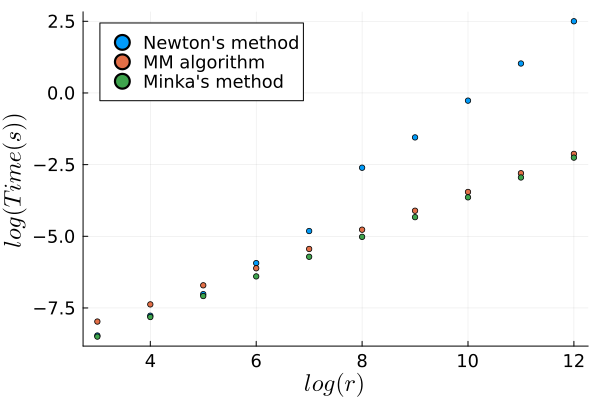

In [10]:
# 1920-1922 year, 8655 fictions
fictions_words_freq = CSV.read("src/Datasets/merged_top20000_words_fiction1.tsv", DataFrame)
# 50000 highest frequency words
top_wards = CSV.read("src/Datasets/top50000_words.csv", DataFrame)

est = []
its1 = Int[]
its2 = Int[]
its3 = Int[]
n = Int[]
p = Int[]
sec1 = Float64[]
sec2 = Float64[]
sec3 = Float64[]
f1 = Float64[]
f2 = Float64[]
f3 = Float64[]

n_divid = 10
for i in range(1, n_divid, n_divid)
    values_to_keep = top_wards[1:2^(Int64(i)+2),1]
    top_wards_filtered = filter(row -> row.word in values_to_keep, fictions_words_freq)
    
    data_mat = Matrix(top_wards_filtered[:, 2:end])
    data_mat[data_mat .== 0] .= 0.01
    row_sums = sum(data_mat, dims=1)
    x = data_mat ./ row_sums
    p1, n1 = size(x)
    push!(n, n1)
    push!(p, p1)
    
    @time (lambda1, iters1) = DirichletMM(x)
    push!(its1, iters1)
    @time (lambda2, iters2) = DirichletNR(x)
    push!(its2, iters2)
    @time (lambda3, iters3) = DirichletMinka(x)
    push!(its3, iters3)
    push!(f1, loglikelihood(Dirichlet(lambda1), x))
    push!(f2, loglikelihood(Dirichlet(lambda2), x))
    push!(f3, loglikelihood(Dirichlet(lambda3), x))
    
    bm = @benchmark DirichletMM($x)
    push!(sec1, median(bm.times) / 1e9)
    bm = @benchmark DirichletNR($x)
    push!(sec2, median(bm.times) / 1e9)
    bm = @benchmark DirichletMinka($x)
    push!(sec3, median(bm.times) / 1e9)

end

results0 = DataFrame(
    n = n,
    p = p,
    Iterations1=its1,
    Iterations2=its2,
    Iterations3=its3,
    Time1=sec1,
    Time2=sec2,
    Time3=sec3,
    LogLik1=f1,
    LogLik2=f2,
    LogLik3=f3
)

results = DataFrame(
    n = n,
    p = p,
    Iterations1=its1,
    Iterations2=its2,
    Time1=sec1,
    Time2=sec2,
    Time3=sec3
)

latex_table = pretty_table(
    results,
    header=["n", "r", "MM Iter", "NR Iter", "MM log(Time) (s)", "NR log(Time) (s)", "Minka log(Time) (s)"],
    formatters=(v, i, j) -> (j == 1 || j == 2 || j == 3|| j == 4) ? Int64(v) : (j == 5 || j == 6 || j == 7 ? round(v, digits=4) : v),
    backend = Val(:latex),
    vlines = :all,
    alignment = :c, 
    compact_printing = false
)

println(latex_table)

g = scatter((Int64.(range(1, n_divid, n_divid)) .+ 2), log.(results.Time2),
            label = "Newton's method",
#             xlabel = L"$r$", 
            tickfontsize = 12,
            legendfontsize = 12,
            xguidefontsize = 16,   # Title font size
            markersize = 3)

scatter!((Int64.(range(1, n_divid, n_divid)) .+ 2), log.(results.Time1),
            label = "MM algorithm",
            xlabel = L"$log(r)$",
            ylabel = L"$log(Time (s))$", 
            tickfontsize = 12,
            legendfontsize = 12,
            xguidefontsize = 16,   # Title font size
            yguidefontsize = 16,   # Title font size
            markersize = 3)


scatter!((Int64.(range(1, n_divid, n_divid)) .+ 2), log.(results.Time3),
            label = "Minka's method",
#             xlabel = L"$r$", 
            tickfontsize = 12,
            legendfontsize = 12,
            xguidefontsize = 16,   # Title font size
            markersize = 3)

display(g)

# savefig(g,"/Users/caleblee/Desktop/dirichlet.pdf")


# Levenberg–Marquardt Algorithm
### Solve least squares $\|y-X\beta\|^2$.

In [11]:
# Hilbert test matrix
Hilbert(n, p) = [1 / (i + j - 1) for i in 1:n, j in 1:p]

savematrix = DataFrame(
    n = Int64[], 
    p = Int64[],  
    Iter = Int64[], 
    Secs=Float64[],
    error=Float64[], 
    mean=Float64[], 
    sd=Float64[], 
    min=Float64[], 
    median=Float64[], 
    max=Float64[])

Random.seed!(123);

for i in range(1,3,3)
    (n, p, d) = (Int64(11*10^i), Int64(10*10^i), 0.001)
    X = Hilbert(n, p);
    cond(X)
    b = ones(p);
    y = X * b + randn(n) / 100;
    XTX = transpose(X) * X;
    XTy = transpose(X) * y;
    mu = d * norm(XTX);

    b = X \ y;
    bm = @benchmark $X \ $y
    bb = summarystats(b)
    push!(savematrix, (n,p, 1, median(bm.times)/1e9, norm(y - X * b), bb.mean, bb.sd, bb.min, bb.median, bb.max))

    (iters1, b) =  Marquardt(y, X, d);
    bm = @benchmark Marquardt($y, $X, $d)
    bb = summarystats(b)
    push!(savematrix, (n,p, 1, median(bm.times)/1e9, norm(y - X * b), bb.mean, bb.sd, bb.min, bb.median, bb.max))

    (iters, b) = MMLS(y, X, d);
    bm = @benchmark MMLS($y, $X, $d)
    bb = summarystats(b)
    push!(savematrix, (n,p, iters, median(bm.times)/1e9, norm(y - X * b), bb.mean, bb.sd, bb.min, bb.median, bb.max))
end

latex_table_LM = pretty_table(
    permutedims(Matrix(savematrix)),
#     header=["n", "p", "Iter", "Secs", "Error", "Mean", "SD", "Min", "Median", "Max"],
    formatters=(v, i, j) -> (i == 1 || i == 2 || i == 3) ? Int64(v) : (i == 4 ||i == 5 || i == 6 || i == 7 || i == 8 || i == 9 || i == 10 ? round(v, digits=4) : v),
    backend = Val(:latex),
    vlines = :all,
    alignment = :c, 
    compact_printing = false
)
println(latex_table_LM)

\begin{tabular}{|c|c|c|c|c|c|c|c|c|}
  \hline
  \textbf{Col. 1} & \textbf{Col. 2} & \textbf{Col. 3} & \textbf{Col. 4} & \textbf{Col. 5} & \textbf{Col. 6} & \textbf{Col. 7} & \textbf{Col. 8} & \textbf{Col. 9} \\\hline
  110 & 110 & 110 & 1100 & 1100 & 1100 & 11000 & 11000 & 11000 \\
  100 & 100 & 100 & 1000 & 1000 & 1000 & 10000 & 10000 & 10000 \\
  1 & 1 & 26 & 1 & 1 & 40 & 1 & 1 & 164 \\
  0.0012 & 0.0001 & 0.0002 & 0.0831 & 0.0158 & 0.0334 & 19.3578 & 3.3537 & 10.5662 \\
  0.0915 & 0.132 & 0.097 & 0.3208 & 0.477 & 0.323 & 1.0482 & 1.6486 & 1.0492 \\
  -994.0293 & 0.9653 & 0.9966 & -44.7048 & 0.9608 & 0.9959 & -4.412 & 0.9572 & 0.9988 \\
  3.3396316646901e9 & 0.1308 & 0.0345 & 4.21352911442e7 & 0.1332 & 0.0559 & 1.6535113122e6 & 0.1367 & 0.0235 \\
  -9.135297342608e9 & 0.749 & 0.8178 & -1.289683465645e8 & 0.7346 & 0.7884 & -6.09035488348e7 & 0.7267 & 0.7547 \\
  -8.42572174417e7 & 0.966 & 1.0053 & 853620.3104 & 0.96 & 1.0029 & 20225.9734 & 0.9554 & 1.0025 \\
  5.7295955582347e9 & 1.15

# Sinkhorn's Algorithm
## Application in Color Transportation

Converged after 12 iterations.


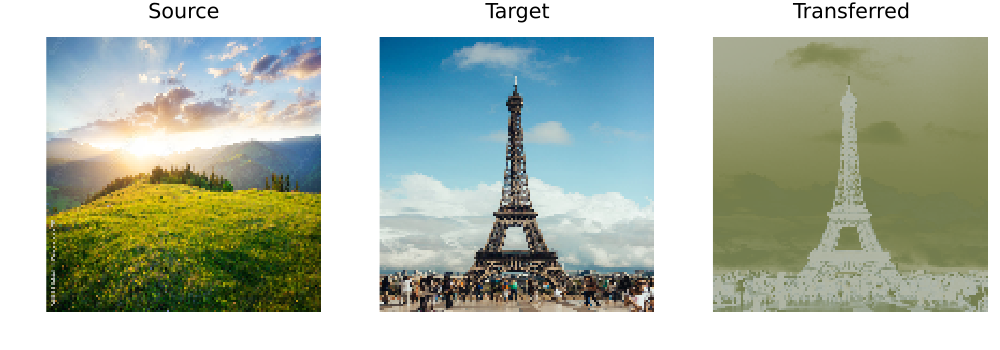

In [12]:
using Images, FileIO, ImageTransformations, Plots, LinearAlgebra, OptimalTransport, Distances

function transfer_color(source_img, target_img, reg0 = 1.0, method = "sinkhorn")
    source_flat = reshape(channelview(float.(source_img)), 3, :)
    target_flat = reshape(channelview(float.(target_img)), 3, :)
    
    a = fill(1.0 / size(source_flat, 2), size(source_flat, 2))
    b = fill(1.0 / size(target_flat, 2), size(target_flat, 2))
    
    M = pairwise(chebyshev, source_flat, target_flat)

    time1 = @elapsed begin
        if method == "sinkhorn"
            G, iters = Sinkhorn(a, b, M, reg0[1])
        elseif method == "ken"
            G, iters = Ken(a, b, M)
        else
            G, iters = OptTransport(a, b, M)
        end
    end
    
    transferred_flat = (source_flat * G) ./ sum(G, dims=1)
    transferred_flat = clamp.(transferred_flat, 0, 1)  
    transferred_img = colorview(RGB, reshape(transferred_flat, 3, size(source_img, 1), size(source_img, 2)))

    return transferred_img, time1, iters
end

source_img = load("src/datasets/day.jpg")
target_img = load("src/datasets/pairs.jpg")
widthnv = 128
depthnv = 128
resized_source_img = imresize(source_img, (widthnv, depthnv))
resized_target_img = imresize(target_img, (widthnv, depthnv))

save("src/datasetscontent_resized.jpg", resized_source_img)
save("src/datasetsstyle_resized.jpg", resized_target_img)

transferred_img1, time1, iters1 = transfer_color(resized_source_img, resized_target_img, 1.0, "ken")
# transferred_img2, time2 = transfer_color(resized_source_img, resized_target_img, 1.0, "sinkhorn")
# transferred_img3 = transfer_color(resized_source_img, resized_target_img, 0.1, "sinkhorn")
# transferred_img4, time4, iters2 = transfer_color(resized_source_img, resized_target_img, 0.05, "optimal_transport")

plot_grid = plot(
    plot(resized_source_img, title="Source", framestyle=:none),
    plot(resized_target_img, title="Target", framestyle=:none),
    plot(transferred_img1, title="Transferred", framestyle=:none),
#     plot(transferred_img2, title="Transferred sin1 Image", framestyle=:none),
#     plot(transferred_img3, title="Transferred sin0.1 Image", framestyle=:none),
#     plot(transferred_img4, title="Transferred opt Image", framestyle=:none),
    layout=(1,3), size=(1000, 350)
)
display(plot_grid)

In [13]:
sec1 = Float64[]
sec4 = Float64[]
n = Int64[]
m = Int64[]
iters = Int64[]

n_divid = 4
for i in range(1, n_divid, n_divid)
    widthnv = Int64(2*2^i)
    depthnv = Int64(2*2^i)
    
    resized_source_img = imresize(source_img, (widthnv, depthnv))
    resized_target_img = imresize(target_img, (widthnv, depthnv))

    transferred_img1, time1, iters1 = transfer_color(resized_source_img, resized_target_img, 1.0, "ken")
    transferred_img4, time4, iters4 = transfer_color(resized_source_img, resized_target_img, 0.05, "optimal_transport")
    
    push!(sec1, time1)
    push!(sec4, time4)
    push!(n, widthnv)
    push!(m, depthnv)
    
end

results = DataFrame(
    n = n,
    m = m,
    iters = iters1,
    Time1=sec1,
    Time2=sec4
)

println(results)

latex_table_Sink = pretty_table(
    results,
    header=["n", "m", "Iter", "Sinkhorn Time (s)", "LP Time (s)"],
    formatters=(v, i, j) -> (j == 1 || j == 2 || j == 3) ? Int64(v) : (j == 4 || j == 5  ? round(v, digits=4) : v),
    backend = Val(:latex),
    vlines = :all,
    alignment = :c, 
    compact_printing = false
)
println(latex_table_Sink)

Converged after 11 iterations.
Converged after 12 iterations.
Converged after 11 iterations.
Converged after 11 iterations.
4×5 DataFrame
 Row │ n      m      iters  Time1        Time2      
     │ Int64  Int64  Int64  Float64      Float64    
─────┼──────────────────────────────────────────────
   1 │     4      4     11  6.55e-5       0.764646
   2 │     8      8     11  0.000207542   0.0179519
   3 │    16     16     11  0.000414167   1.06811
   4 │    32     32     11  0.00737242   92.2494
\begin{tabular}{|c|c|c|c|c|}
  \hline
  \textbf{n} & \textbf{m} & \textbf{Iter} & \textbf{Sinkhorn Time (s)} & \textbf{LP Time (s)} \\\hline
  4 & 4 & 11 & 0.0001 & 0.7646 \\
  8 & 8 & 11 & 0.0002 & 0.018 \\
  16 & 16 & 11 & 0.0004 & 1.0681 \\
  32 & 32 & 11 & 0.0074 & 92.2494 \\\hline
\end{tabular}
nothing
